# Task 6: Simple Bidirectional LSTM Cell Mechanics from Scratch

Understand forward and backward sequence updates in an LSTM using simple step-by-step tensor math.

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

### 1. Sequence Data & LSTM Weights

In [2]:
seq_len = 5
input_dim, hidden_dim = 2, 4
x_seq = torch.randn(seq_len, input_dim)  # 5 time steps

# Weights for gates (input, forget, cell, output)
W_fwd = torch.randn(input_dim + hidden_dim, 4 * hidden_dim) * 0.1
W_bwd = torch.randn(input_dim + hidden_dim, 4 * hidden_dim) * 0.1

### 2. Forward & Backward Sequential Loop

In [3]:
# --- FORWARD PASS (t = 0 to 4) ---
h_f = torch.zeros(1, hidden_dim)
c_f = torch.zeros(1, hidden_dim)
fwd_states = []

for t in range(seq_len):
    combined = torch.cat([x_seq[t:t+1], h_f], dim=1)
    gates = combined @ W_fwd
    i, f, g, o = torch.chunk(gates, 4, dim=1)
    c_f = torch.sigmoid(f) * c_f + torch.sigmoid(i) * torch.tanh(g)
    h_f = torch.sigmoid(o) * torch.tanh(c_f)
    fwd_states.append(h_f)

# --- BACKWARD PASS (t = 4 down to 0) ---
h_b = torch.zeros(1, hidden_dim)
c_b = torch.zeros(1, hidden_dim)
bwd_states = []

for t in reversed(range(seq_len)):
    combined = torch.cat([x_seq[t:t+1], h_b], dim=1)
    gates = combined @ W_bwd
    i, f, g, o = torch.chunk(gates, 4, dim=1)
    c_b = torch.sigmoid(f) * c_b + torch.sigmoid(i) * torch.tanh(g)
    h_b = torch.sigmoid(o) * torch.tanh(c_b)
    bwd_states.insert(0, h_b)

### 3. Concatenate Forward + Backward Hidden States

BiLSTM Output Shape: torch.Size([5, 8])


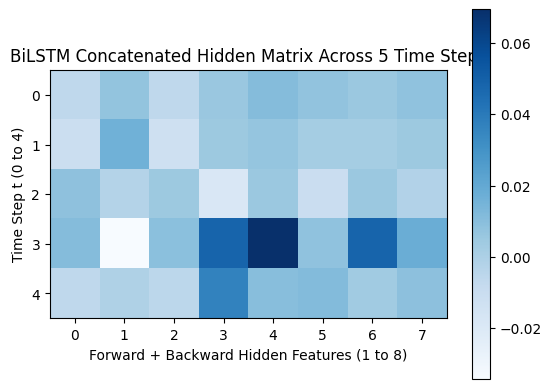

In [4]:
fwd_out = torch.cat(fwd_states, dim=0)
bwd_out = torch.cat(bwd_states, dim=0)
bilstm_out = torch.cat([fwd_out, bwd_out], dim=1)  # Combine both directions

print('BiLSTM Output Shape:', bilstm_out.shape)  # (5 time steps, 8 hidden features)
plt.imshow(bilstm_out.detach().numpy(), cmap='Blues')
plt.title('BiLSTM Concatenated Hidden Matrix Across 5 Time Steps')
plt.xlabel('Forward + Backward Hidden Features (1 to 8)')
plt.ylabel('Time Step t (0 to 4)')
plt.colorbar()
plt.show()